#### **GPU Checking**

In [ ]:
print("TF version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

2026-02-08 17:15:39.917113: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770570940.285493      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770570940.407082      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770570941.337692      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770570941.337734      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770570941.337737      55 computation_placer.cc:177] computation placer alr

TF version: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]



### **Imports and Configuration (Kaggle)**

This cell initializes the deep learning environment and training configuration for the Malaria Cell Classification system.

---

#### **Reproducibility Seed**

```python
SEED = 42
tf.keras.utils.set_random_seed(SEED)
```

Ensures consistent results across runs by fixing randomness in:

* Weight initialization
* Data shuffling
* Augmentation

---

#### **Image Size Configuration**

```python
IMG_SIZE = (64, 64)
```

Resizes each malaria cell image to **64×64 pixels** so all inputs have a uniform shape for CNN processing.

Smaller size → faster training
Larger size → more detail but slower computation

---

#### **Batch Size**

```python
BATCH_SIZE = 32
```

Defines how many images are processed in one training step.

Balances:

* Training speed
* Memory usage
* Gradient stability

---

#### **Epochs**

```python
EPOCHS = 8
```

Specifies the number of full passes over the dataset during training.

More epochs → more learning but higher overfitting risk.

---

#### **Dataset Directory (Kaggle Path)**

```python
DATA_DIR = "/kaggle/input/cell-images-for-detecting-malaria/cell_images"
```

Points to the malaria dataset mounted automatically in Kaggle’s `/input/` directory.

Dataset contains two folders:

* **Uninfected**
* **Parasitized**

---

#### **Class Label Mapping**

```python
CLASS_NAMES = ["Uninfected", "Parasitized"]
```

Defines label meaning for evaluation:

* `0 → Uninfected (Negative)`
* `1 → Parasitized (Positive)`

Important for medical metrics like Recall and Sensitivity.

---

#### **Environment Checks**

```python
print("TF version:", tf.__version__)
print("DATA_DIR exists?", os.path.exists(DATA_DIR))
print("Input datasets:", os.listdir("/kaggle/input")[:10])
```

Verifies:

* TensorFlow installation
* Dataset availability
* Kaggle input mounting



In [ ]:
import os, json
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve



# Reproducibility
SEED = 42
tf.keras.utils.set_random_seed(SEED)

# Training config
IMG_SIZE = (64, 64)
BATCH_SIZE = 32
EPOCHS = 8

# Dataset path on Kaggle: datasets are mounted under /kaggle/input/ [web:62]
DATA_DIR = "/kaggle/input/cell-images-for-detecting-malaria/cell_images"

# Fix label meaning (important for medical metrics):
# 0 -> Uninfected, 1 -> Parasitized (positive class)
CLASS_NAMES = ["Uninfected", "Parasitized"]

print("TF version:", tf.__version__)
print("DATA_DIR exists?", os.path.exists(DATA_DIR))
print("Input datasets:", os.listdir("/kaggle/input")[:10])


TF version: 2.19.0
DATA_DIR exists? True
Input datasets: ['cell-images-for-detecting-malaria']


---

### Dataset Sanity Check

* Prints the **dataset directory path** stored in `DATA_DIR`.
* Lists all **subfolders inside the dataset directory** (usually class folders).
* Loops through each class name in `CLASS_NAMES`.
* Builds the **full path** for each class folder using `os.path.join`.
* Checks if the folder exists:

  * If missing → raises `FileNotFoundError`.
* Defines supported **image extensions**:

  * `.png`, `.jpg`, `.jpeg`, `.bmp`.
* Filters files in the class folder to only include image files.
* Counts total images in that class.
* Prints:

  * Class name.
  * Number of images.
  * Example file name (first image).

---




In [ ]:
# Cell 2: Dataset sanity check (structure + quick counts)

print("DATA_DIR:", DATA_DIR)
print("Subfolders in DATA_DIR:", os.listdir(DATA_DIR))

for cname in CLASS_NAMES:
    cpath = os.path.join(DATA_DIR, cname)
    if not os.path.exists(cpath):
        raise FileNotFoundError(f"Missing folder: {cpath}")

    # Count a few image types (Kaggle dataset is mostly png)
    exts = (".png", ".jpg", ".jpeg", ".bmp")
    files = [f for f in os.listdir(cpath) if f.lower().endswith(exts)]
    print(f"{cname}: {len(files)} images | example file: {files[0] if len(files)>0 else 'None'}")


DATA_DIR: /kaggle/input/cell-images-for-detecting-malaria/cell_images
Subfolders in DATA_DIR: ['Uninfected', 'Parasitized', 'cell_images']
Uninfected: 13779 images | example file: C203ThinF_IMG_20151029_102123_cell_51.png
Parasitized: 13779 images | example file: C99P60ThinF_IMG_20150918_141001_cell_93.png



---

## Image Loading + Splitting

### Creating Training Dataset — `train_ds`

* Loads images from `DATA_DIR`.
* Automatically **infers labels from folder names**.
* Uses **binary labels (0 / 1 floats)** via `label_mode="binary"`.
* Forces class order using `CLASS_NAMES`:

  * `0 → Uninfected`
  * `1 → Parasitized`
* Splits dataset:

  * **80% → Training**
  * via `validation_split=0.20` + `subset="training"`.
* Uses `SEED` for reproducible split.
* Resizes images to `IMG_SIZE`.
* Loads data in batches using `BATCH_SIZE`.
* Shuffles training data.

---

### Creating Validation+Test Pool — `valtest_ds`

* Loads from the same directory again.
* Uses the **remaining 20%** of data.
* `subset="validation"` → gets validation portion from split.
* Same settings:

  * Binary labels
  * Class order
  * Image resize
  * Batch size
  * Shuffle enabled

*(You’ll later split this into validation + test if needed.)*

---

### Printing Dataset Info

* `train_ds.class_names`

  * Confirms class label mapping order.
* `next(iter(train_ds))`

  * Grabs one batch.
* Prints shapes:

  * **Images batch shape** → `(batch_size, height, width, channels)`
  * **Labels batch shape** → `(batch_size, 1)`

---



In [ ]:
# Cell 3: Load images using image_dataset_from_directory (train + valtest)

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    labels="inferred",
    label_mode="binary",              # outputs labels shaped (batch, 1) as 0/1 floats
    class_names=CLASS_NAMES,          # ensures 0=Uninfected, 1=Parasitized
    validation_split=0.20,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

valtest_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    labels="inferred",
    label_mode="binary",
    class_names=CLASS_NAMES,
    validation_split=0.20,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

print("Dataset class_names:", train_ds.class_names)
print("One batch shapes:", next(iter(train_ds))[0].shape, next(iter(train_ds))[1].shape)


Found 27558 files belonging to 2 classes.
Using 22047 files for training.


I0000 00:00:1770571236.198900      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1770571236.204815      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 27558 files belonging to 2 classes.
Using 5511 files for validation.
Dataset class_names: ['Uninfected', 'Parasitized']
One batch shapes: (32, 64, 64, 3) (32, 1)



---

## Validation / Test Split

### Count total batches in `valtest_ds`

* `tf.data.experimental.cardinality(valtest_ds)`

  * Counts how many **batches** exist.
* `.numpy()` converts tensor → integer.
* Stored in `valtest_batches`.

---

### Calculate 50/50 split

* `val_batches = valtest_batches // 2`
* Uses integer division.
* Half batches → Validation.
* Half → Test.

---

### Create Validation Dataset — `val_ds`

* `valtest_ds.take(val_batches)`
* Takes **first half** of batches.
* Used during training for performance monitoring.

---

### Create Test Dataset — `test_ds`

* `valtest_ds.skip(val_batches)`
* Skips first half.
* Remaining batches → Test set.
* Used for final unbiased evaluation.

---

### Print batch counts

* Prints:

  * Total valtest batches.
  * Validation batches.
  * Test batches.
* Confirms split worked correctly.

---


In [ ]:
# Cell 4: Split valtest into validation + test (50/50 by batches)

valtest_batches = tf.data.experimental.cardinality(valtest_ds).numpy()
val_batches = valtest_batches // 2

val_ds = valtest_ds.take(val_batches)
test_ds = valtest_ds.skip(val_batches)

print("valtest batches:", valtest_batches)
print("val batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("test batches:", tf.data.experimental.cardinality(test_ds).numpy())


valtest batches: 173
val batches: 86
test batches: 87


---

## Preprocessing + Performance Boost

### Enable automatic performance tuning

* `AUTOTUNE = tf.data.AUTOTUNE`
* Lets TensorFlow decide:

  * Best parallelism
  * Best prefetch size
* Optimizes input pipeline speed ⚡

---

### Create Normalization Layer

* `layers.Rescaling(1./255)`
* Converts pixel range:

  * From **0–255** → **0–1**
* Helps model train faster + more stable.

---

### Define `preprocess()` function

Steps applied to each batch:

* `tf.cast(x, tf.float32)`

  * Converts images → float32.
* Apply normalization layer.
* Returns processed `(x, y)`.

---

### Apply preprocessing to datasets

Using `.map()`:

* `train_ds_pp`
* `val_ds_pp`
* `test_ds_pp`

Each gets:

* Normalization
* Type casting

---

### Parallel processing

* `num_parallel_calls=AUTOTUNE`
* Processes multiple batches simultaneously.
* Speeds up loading + preprocessing.

---

### Cache dataset

* `.cache()`
* Stores dataset in memory after first pass.
* Avoids reloading images every epoch.
* Huge training speed boost 🚀

---

### Prefetch batches

* `.prefetch(AUTOTUNE)`
* Loads next batch while model trains on current.
* Prevents GPU/CPU idle time.

---

## Sanity check

```python
x0, y0 = next(iter(train_ds_pp))
```

* Takes one processed batch.

Prints:

* Min pixel value.
* Max pixel value.
* Label shape.

Expected:

* Range → **0.0 to 1.0** ✅

---




In [ ]:
# Cell 5: Preprocess (normalize) + speed up pipeline

AUTOTUNE = tf.data.AUTOTUNE
normalizer = layers.Rescaling(1./255)

def preprocess(x, y):
    x = tf.cast(x, tf.float32)
    x = normalizer(x)
    return x, y

train_ds_pp = train_ds.map(preprocess, num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)
val_ds_pp   = val_ds.map(preprocess,   num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)
test_ds_pp  = test_ds.map(preprocess,  num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)

# Quick check: value range should be 0..1
x0, y0 = next(iter(train_ds_pp))
print("Batch x min/max:", float(tf.reduce_min(x0)), float(tf.reduce_max(x0)), "| y shape:", y0.shape)


Batch x min/max: 0.0 0.8968290686607361 | y shape: (32, 1)



---

## Build + Compile CNN

### Create Sequential CNN Model

```python
model = keras.Sequential([...])
```

* Builds a **layer-by-layer CNN**.
* Used for **image classification**.

Input → Feature Extraction → Classification.

---

## Input Layer

```python
layers.Input(shape=(64, 64, 3))
```

* Image size: **64×64**
* `3` = RGB channels.
* Defines model input shape.

---

## Convolution Blocks (Feature Extraction)

### Block 1

```python
Conv2D(32, 3x3) → MaxPooling
```

* 32 filters detect:

  * Edges
  * Textures
* Pooling reduces spatial size.

---

### Block 2

```python
Conv2D(64, 3x3) → MaxPooling
```

* Learns more complex features:

  * Cell shapes
  * Parasite patterns

---

### Block 3

```python
Conv2D(128, 3x3) → MaxPooling
```

* Deep features:

  * Infection structures
  * Detailed morphology

 Filters increase → model learns richer patterns.

---

## Flatten Layer

```python
layers.Flatten()
```

* Converts feature maps → 1D vector.
* Required for Dense layers.

---

## Regularization (Dropout)

```python
Dropout(0.5)
Dropout(0.3)
```

* Randomly disables neurons.
* Prevents **overfitting**.
* Forces model to generalize better.

---

## Dense (Fully Connected) Layer

```python
Dense(128, activation="relu")
```

* Learns classification patterns.
* Combines extracted features.

---

## Output Layer

```python
Dense(1, activation="sigmoid")
```

* Binary classification.
* Outputs probability:

| Value | Meaning     |
| ----- | ----------- |
| 0 →   | Uninfected  |
| 1 →   | Parasitized |

---

## Compile Model

Defines training setup 👇

---

### Optimizer

```python
Adam(learning_rate=1e-3)
```

* Adjusts weights.
* Adaptive + fast convergence.

---

### Loss Function

```python
BinaryCrossentropy()
```

* Measures prediction error.
* Used for binary classification.

---

### Metrics

```python
BinaryAccuracy → correctness
AUC → class separation quality
```

Why AUC?

* Important for medical diagnosis.
* Measures detection capability.

---

## Model Summary

```python
model.summary()
```

Displays:

* Layer stack
* Output shapes
* Trainable parameters

---


In [ ]:
# Cell 6: Build + compile a small CNN

model = keras.Sequential([
    layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),

    # Block 1
    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D(),

    # Block 2
    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D(),

    # Block 3
    layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D(),

    # Classifier head
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(1, activation="sigmoid")  # P(Parasitized)
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[
        keras.metrics.BinaryAccuracy(name="acc"),
        keras.metrics.AUC(name="auc")
    ]
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,142,081 (4.36 MB)

 Trainable params: 1,142,081 (4.36 MB)

 Non-trainable params: 0 (0.00 B)



---

## Model Training + Early Stopping

This cell trains the CNN while preventing overfitting using **EarlyStopping**.

---

## EarlyStopping Callback

```python
keras.callbacks.EarlyStopping(...)
```

Stops training automatically when validation performance stops improving.

---

### Monitor Metric

```python
monitor="val_auc"
```

* Tracks **Validation AUC**.
* AUC is critical for medical models.
* Measures how well model separates infected vs uninfected.

---

### Mode

```python
mode="max"
```

* Training continues while AUC increases.
* Stops when AUC stops improving.

---

### Patience

```python
patience=3
```

* Waits **3 epochs** for improvement.
* If no improvement → training stops.

Prevents wasting compute + overfitting.

---

### Restore Best Weights

```python
restore_best_weights=True
```

* Loads weights from best AUC epoch.
* Ensures final model = best performer (not last epoch).

---

## Model Training

```python
model.fit(...)
```

Starts training process.

---

### Training Data

```python
train_ds_pp
```

* Preprocessed training dataset.
* Normalized + optimized pipeline.

---

### Validation Data

```python
validation_data=val_ds_pp
```

* Used to evaluate model each epoch.
* Drives EarlyStopping decisions.

---

### Epochs

```python
epochs=EPOCHS
```

* Max training cycles (e.g., 8).
* May stop earlier due to EarlyStopping.

---

### Callbacks

```python
callbacks=callbacks
```

* Applies EarlyStopping during training.

---

### Verbose

```python
verbose=1
```

* Shows live training logs:

  * Loss
  * Accuracy
  * AUC
  * Validation metrics

---


In [ ]:
# Cell 7: Train with EarlyStopping (monitor validation AUC)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=3,
        restore_best_weights=True
    )
]

history = model.fit(
    train_ds_pp,
    validation_data=val_ds_pp,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/8


I0000 00:00:1770571772.196325     146 service.cc:152] XLA service 0x7b573c00e6c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1770571772.196374     146 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1770571772.196379     146 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1770571772.846404     146 cuda_dnn.cc:529] Loaded cuDNN version 91002


 10/689 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - acc: 0.5194 - auc: 0.4152 - loss: 0.7422 

I0000 00:00:1770571777.707320     146 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


689/689 ━━━━━━━━━━━━━━━━━━━━ 60s 77ms/step - acc: 0.7584 - auc: 0.8289 - loss: 0.4644 - val_acc: 0.9491 - val_auc: 0.9845 - val_loss: 0.1482
Epoch 2/8
689/689 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - acc: 0.9490 - auc: 0.9823 - loss: 0.1569 - val_acc: 0.9589 - val_auc: 0.9885 - val_loss: 0.1323
Epoch 3/8
689/689 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - acc: 0.9561 - auc: 0.9850 - loss: 0.1414 - val_acc: 0.9597 - val_auc: 0.9881 - val_loss: 0.1316
Epoch 4/8
689/689 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - acc: 0.9580 - auc: 0.9876 - loss: 0.1311 - val_acc: 0.9618 - val_auc: 0.9891 - val_loss: 0.1208
Epoch 5/8
689/689 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - acc: 0.9584 - auc: 0.9889 - loss: 0.1233 - val_acc: 0.9604 - val_auc: 0.9883 - val_loss: 0.1230
Epoch 6/8
689/689 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - acc: 0.9607 - auc: 0.9897 - loss: 0.1189 - val_acc: 0.9618 - val_auc: 0.9889 - val_loss: 0.1225
Epoch 7/8
689/689 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - acc: 0.9606 - auc: 0.9907 - loss: 0.1123 - val_acc: 0.9618 - 



---

## Learning Curves (Train vs Validation)

This cell visualizes model performance across epochs.

---

## Training History Keys

```python
history.history.keys()
```

Shows all tracked metrics, e.g.:

* loss / val_loss
* acc / val_acc
* auc / val_auc

Confirms what can be plotted.

---

## Figure Setup

```python
plt.figure(figsize=(14,4))
```

Creates a wide plot canvas for 3 graphs side-by-side.

---

## Loss Curve

```python
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
```

Shows training vs validation loss.

**Purpose:**

* Decreasing train + val → good learning
* Train ↓ but val ↑ → overfitting
* Both high → underfitting

---

## Accuracy Curve

```python
plt.plot(history.history["acc"])
plt.plot(history.history["val_acc"])
```

Tracks classification accuracy.

**Goal:** Both curves increase and stay close.

---

## AUC Curve

```python
plt.plot(history.history["auc"])
plt.plot(history.history["val_auc"])
```

Measures class separation ability.

Important for medical diagnosis models.

Higher AUC = better infected vs healthy detection.

---

## Subplots Layout

```python
plt.subplot(1, 3, i)
```

Creates 3 plots in one row:

1. Loss
2. Accuracy
3. AUC

---

## Final Formatting

```python
plt.tight_layout()
plt.show()
```

* Fixes spacing
* Displays all curves cleanly

---




History keys: ['acc', 'auc', 'loss', 'val_acc', 'val_auc', 'val_loss']


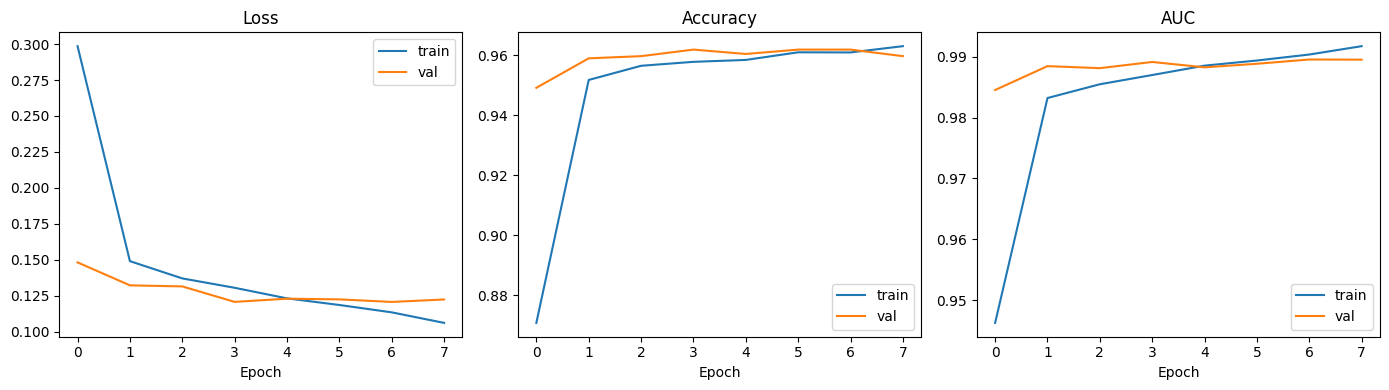

In [ ]:
# Cell 8: Learning curves (train vs val)

keys = list(history.history.keys())
print("History keys:", keys)

plt.figure(figsize=(14,4))

# Loss
plt.subplot(1, 3, 1)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss")
plt.xlabel("Epoch")
plt.legend()

# Accuracy
plt.subplot(1, 3, 2)
plt.plot(history.history["acc"], label="train")
plt.plot(history.history["val_acc"], label="val")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.legend()

# AUC
plt.subplot(1, 3, 3)
plt.plot(history.history["auc"], label="train")
plt.plot(history.history["val_auc"], label="val")
plt.title("AUC")
plt.xlabel("Epoch")
plt.legend()

plt.tight_layout()
plt.show()




---

## Test Set Evaluation (Full Metrics + ROC)

This cell evaluates final model performance on unseen test data.

---

## Collect Predictions

```python
for x_batch, y_batch in test_ds_pp:
```

* Loops through test dataset in batches
* Avoids memory overload
* Works efficiently on large image data

---

## Predicted Probabilities

```python
model.predict(x_batch)
```

* Outputs probability of **Parasitized (class 1)**
* Range: 0 → 1
* Stored in `y_prob`

---

## True Labels Collection

```python
y_true.extend(y_batch.numpy())
```

* Converts tensor → numpy
* Stores actual labels for comparison

---

## Convert to Arrays

```python
y_true = np.array(...)
y_prob = np.array(...)
```

Makes data ready for sklearn metrics.

---

## Apply Classification Threshold

```python
y_pred = (y_prob >= 0.5).astype(int)
```

* ≥ 0.5 → Parasitized
* < 0.5 → Uninfected
* Converts probabilities → class labels

---

## Sanity Check

```python
np.unique(y_true), np.unique(y_pred)
```

Confirms both classes exist in predictions.

---

## ROC-AUC Score

```python
roc_auc_score(y_true, y_prob)
```

* Threshold-independent metric
* Measures class separability
* Higher = better diagnosis performance

---

## Confusion Matrix

```python
cm = confusion_matrix(...)
```

Layout:

|        | Pred 0 | Pred 1 |
| ------ | ------ | ------ |
| True 0 | TN     | FP     |
| True 1 | FN     | TP     |

Medical meaning:

* **FN** → Missed infected patient ❌ (critical)
* **FP** → False alarm ⚠️

---

## Extract TN FP FN TP

```python
tn, fp, fn, tp = cm.ravel()
```

Used for deeper metric analysis.

---

## Precision / Recall / F1

```python
classification_report(...)
```

Gives:

* Precision → prediction correctness
* Recall → infection detection rate
* F1 → balance of both

Key in healthcare models.

---

## ROC Curve Plot

```python
roc_curve(y_true, y_prob)
```

Plots:

* **FPR** → False positive rate
* **TPR** → Recall / Sensitivity

---

## Visualization

```python
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],"--")
```

* Blue curve → model performance
* Diagonal → random guessing baseline

Closer to top-left = better model.

---


Unique y_true: [0 1] Unique y_pred: [0 1]
Test ROC-AUC: 0.989718144957025

Confusion Matrix (rows=true, cols=pred) labels=[Uninfected(0), Parasitized(1)]
[[1333   54]
 [  75 1297]]

TN=1333, FP=54, FN=75, TP=1297

Classification report:
              precision    recall  f1-score   support

  Uninfected     0.9467    0.9611    0.9538      1387
 Parasitized     0.9600    0.9453    0.9526      1372

    accuracy                         0.9532      2759
   macro avg     0.9534    0.9532    0.9532      2759
weighted avg     0.9533    0.9532    0.9532      2759



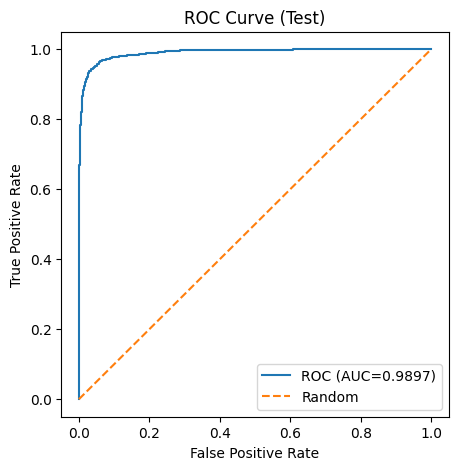

In [ ]:
# Cell 9: Evaluate on TEST set (confusion matrix, PRF1, ROC-AUC, ROC curve)

# Collect true labels and predicted probabilities
y_true, y_prob = [], []

for x_batch, y_batch in test_ds_pp:
    prob = model.predict(x_batch, verbose=0).reshape(-1)          # P(Parasitized=1)
    y_prob.extend(prob.tolist())
    y_true.extend(y_batch.numpy().reshape(-1).tolist())

y_true = np.array(y_true).astype(int)
y_prob = np.array(y_prob)
y_pred = (y_prob >= 0.5).astype(int)

print("Unique y_true:", np.unique(y_true), "Unique y_pred:", np.unique(y_pred))

# ROC-AUC (threshold-free)
auc = roc_auc_score(y_true, y_prob)
print("Test ROC-AUC:", auc)

# Confusion matrix: rows=true, cols=pred
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix (rows=true, cols=pred) labels=[Uninfected(0), Parasitized(1)]")
print(cm)
print(f"\nTN={tn}, FP={fp}, FN={fn}, TP={tp}")

# Precision / Recall / F1
print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

# ROC curve plot
fpr, tpr, thresholds = roc_curve(y_true, y_prob)

plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, label=f"ROC (AUC={auc:.4f})")
plt.plot([0, 1], [0, 1], "--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test)")
plt.legend()
plt.show()


In [ ]:
# Cell 10: Save trained model + class names

MODEL_KERAS_PATH = "malaria_cnn.keras"
MODEL_SAVEDMODEL_DIR = "malaria_savedmodel"
CLASSNAMES_PATH = "class_names.json"

# Save in Keras v3 format (.keras)
model.save(MODEL_KERAS_PATH)

# Also save in SavedModel directory format (optional but useful)
model.save(MODEL_SAVEDMODEL_DIR)

# Save class names to keep label mapping consistent in inference/FastAPI
with open(CLASSNAMES_PATH, "w") as f:
    json.dump(CLASS_NAMES, f)

print("Saved:", MODEL_KERAS_PATH)
print("Saved:", MODEL_SAVEDMODEL_DIR)
print("Saved:", CLASSNAMES_PATH)

!ls -lah


ValueError: Invalid filepath extension for saving. Please add either a `.keras` extension for the native Keras format (recommended) or a `.h5` extension. Use `model.export(filepath)` if you want to export a SavedModel for use with TFLite/TFServing/etc. Received: filepath=malaria_savedmodel.

In [ ]:
# Cell 10 (updated): Save model correctly in TF 2.19 / Keras 3

import os, json

MODEL_KERAS_PATH = "malaria_cnn.keras"      # OK for model.save()
MODEL_SAVEDMODEL_DIR = "malaria_savedmodel" # use model.export() for this
CLASSNAMES_PATH = "class_names.json"

# 1) Save in native Keras format (.keras)
model.save(MODEL_KERAS_PATH)

# 2) Export as TensorFlow SavedModel (directory)
# (This is what TF Serving / TFLite workflows typically use)
model.export(MODEL_SAVEDMODEL_DIR, format="tf_saved_model")

# 3) Save class names for consistent inference
with open(CLASSNAMES_PATH, "w") as f:
    json.dump(CLASS_NAMES, f)

print("Saved:", MODEL_KERAS_PATH)
print("Exported SavedModel dir:", MODEL_SAVEDMODEL_DIR)
print("Saved:", CLASSNAMES_PATH)

!ls -lah
!find malaria_savedmodel -maxdepth 2 -type f | head -n 20


INFO:tensorflow:Assets written to: malaria_savedmodel/assets


INFO:tensorflow:Assets written to: malaria_savedmodel/assets


Saved artifact at 'malaria_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  135617406249744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135617406250128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135617406251472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135617406252048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135617406252432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135617406248016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135617406252624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135617406251280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135617406251088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135617406253008: TensorSpec(shape=(), dtype=tf.resource, name=None)
Saved: malaria_c

In [ ]:
import shutil
shutil.make_archive("malaria_savedmodel", "zip", "malaria_savedmodel")
!ls -lah malaria_savedmodel.zip


-rw-r--r-- 1 root root 8.2M Feb  8 17:39 malaria_savedmodel.zip
